# Netflix / Media Dataset EDA

This notebook explores the Netflix Movies and TV Shows dataset. It generates counts by type, year trends, top genres, runtime distributions, top-10 lists, plots, and exported summary files.

Place `netflix_titles.csv` in this folder before running, or run the Python script to auto-download from Zenodo.

## 1. Import libraries and setup

In [8]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import kagglehub

# =========================================================
# Netflix / Media Dataset EDA Project
# Dataset Source:
# https://www.kaggle.com/datasets/shivamb/netflix-shows
# =========================================================

# Download dataset from Kaggle
dataset_path = kagglehub.dataset_download("shivamb/netflix-shows")

# Load CSV file
DATA_PATH = Path(dataset_path) / "netflix_titles.csv"

# Output folders
BASE_DIR = Path.cwd()
OUTPUT_DIR = BASE_DIR / "outputs"
PLOTS_DIR = OUTPUT_DIR / "plots"

OUTPUT_DIR.mkdir(exist_ok=True)
PLOTS_DIR.mkdir(exist_ok=True)



100%|██████████| 1.34M/1.34M [00:01<00:00, 1.05MB/s]

Extracting files...


## 2. Load dataset

In [9]:
# Read dataset
df = pd.read_csv(DATA_PATH)

# Preview dataset
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


## 3. Clean and prepare data

In [10]:
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
df['date_added'] = pd.to_datetime(df['date_added'].astype(str).str.strip(), errors='coerce')
df['year_added'] = df['date_added'].dt.year
df['release_year'] = pd.to_numeric(df['release_year'], errors='coerce')
df['duration_num'] = df['duration'].astype(str).str.extract(r'(\d+)').astype(float)
df['duration_unit'] = df['duration'].astype(str).str.extract(r'([A-Za-z]+)')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   show_id        8807 non-null   object        
 1   type           8807 non-null   object        
 2   title          8807 non-null   object        
 3   director       6173 non-null   object        
 4   cast           7982 non-null   object        
 5   country        7976 non-null   object        
 6   date_added     8797 non-null   datetime64[ns]
 7   release_year   8807 non-null   int64         
 8   rating         8803 non-null   object        
 9   duration       8804 non-null   object        
 10  listed_in      8807 non-null   object        
 11  description    8807 non-null   object        
 12  year_added     8797 non-null   float64       
 13  duration_num   8804 non-null   float64       
 14  duration_unit  8807 non-null   object        
dtypes: datetime64[ns](1),

## 4. Count by type

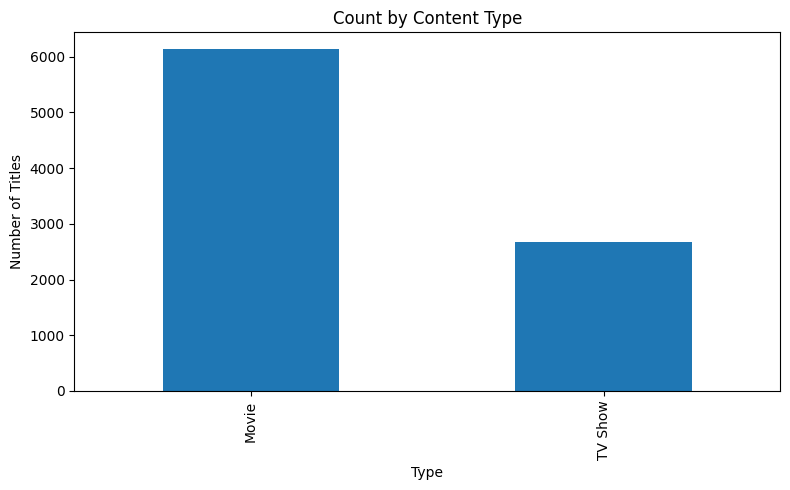

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

In [11]:
type_counts = df['type'].value_counts()
type_counts.plot(kind='bar', figsize=(8,5), title='Count by Content Type')
plt.xlabel('Type')
plt.ylabel('Number of Titles')
plt.tight_layout()
plt.savefig(PLOTS_DIR / '01_type_counts.png', dpi=160)
plt.show()
type_counts

## 5. Release year trend

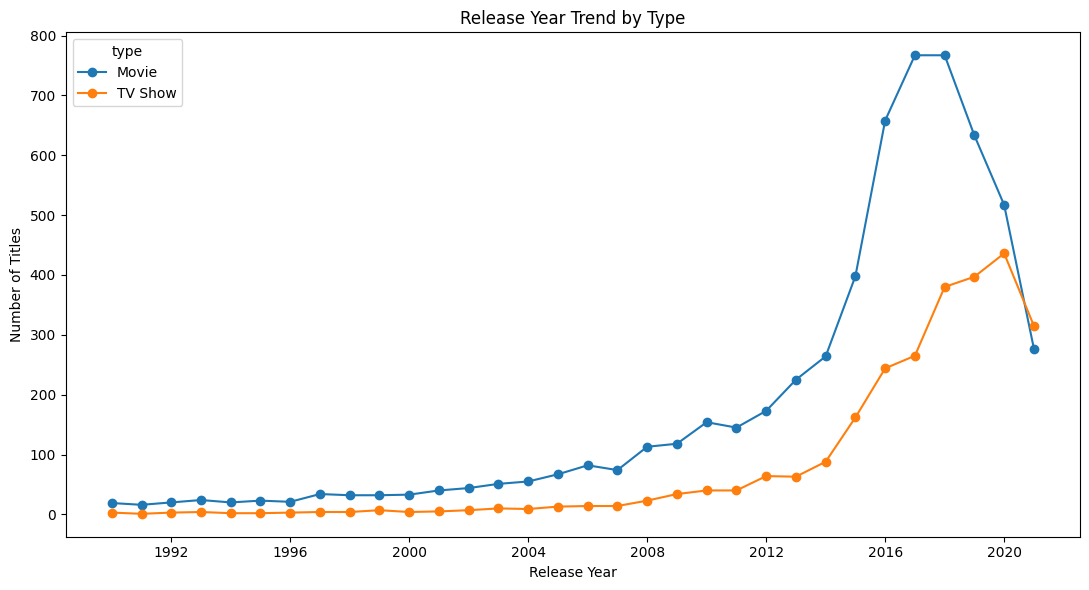

In [12]:
release_trend = df.pivot_table(index='release_year', columns='type', values='show_id', aggfunc='count').fillna(0)
release_trend = release_trend[release_trend.index >= 1990]
release_trend.plot(figsize=(11,6), marker='o', title='Release Year Trend by Type')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
plt.tight_layout()
plt.savefig(PLOTS_DIR / '02_release_year_trend.png', dpi=160)
plt.show()

## 6. Content growth by date added

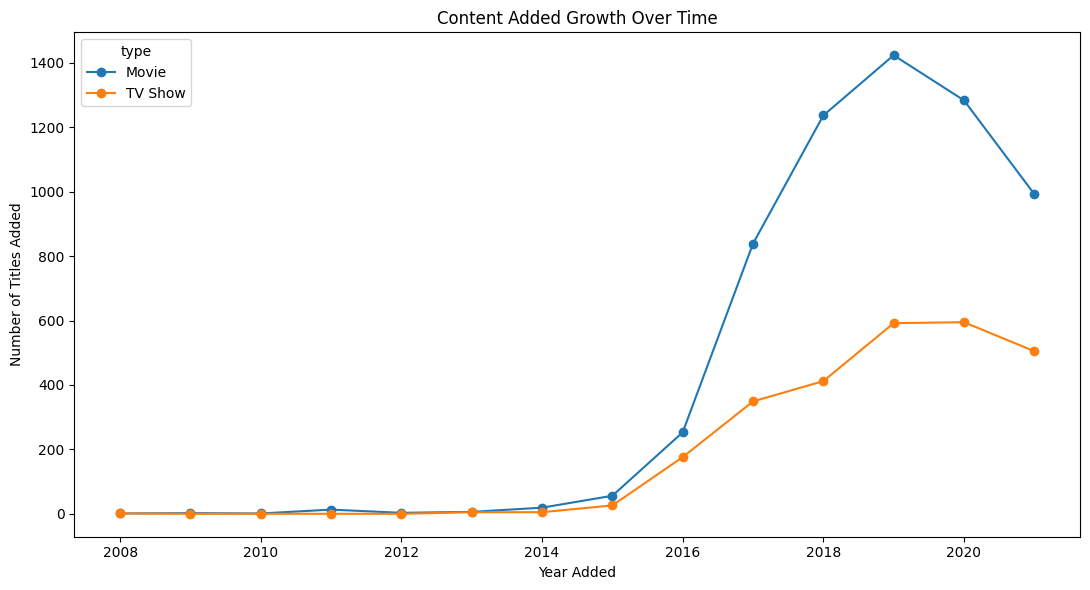

In [13]:
added_growth = df.pivot_table(index='year_added', columns='type', values='show_id', aggfunc='count').fillna(0)
added_growth.plot(figsize=(11,6), marker='o', title='Content Added Growth Over Time')
plt.xlabel('Year Added')
plt.ylabel('Number of Titles Added')
plt.tight_layout()
plt.savefig(PLOTS_DIR / '03_content_added_growth.png', dpi=160)
plt.show()

## 7. Top genres

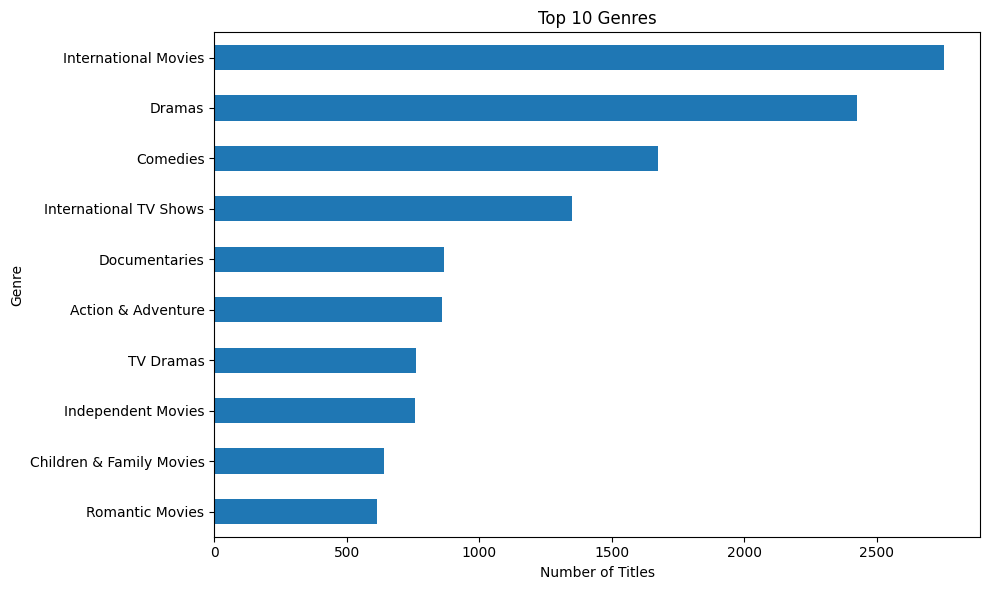

listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64

In [14]:
genres = df['listed_in'].dropna().str.split(', ').explode()
top_genres = genres.value_counts().head(10)
top_genres.sort_values().plot(kind='barh', figsize=(10,6), title='Top 10 Genres')
plt.xlabel('Number of Titles')
plt.ylabel('Genre')
plt.tight_layout()
plt.savefig(PLOTS_DIR / '04_top_genres.png', dpi=160)
plt.show()
top_genres

## 8. Runtime distributions

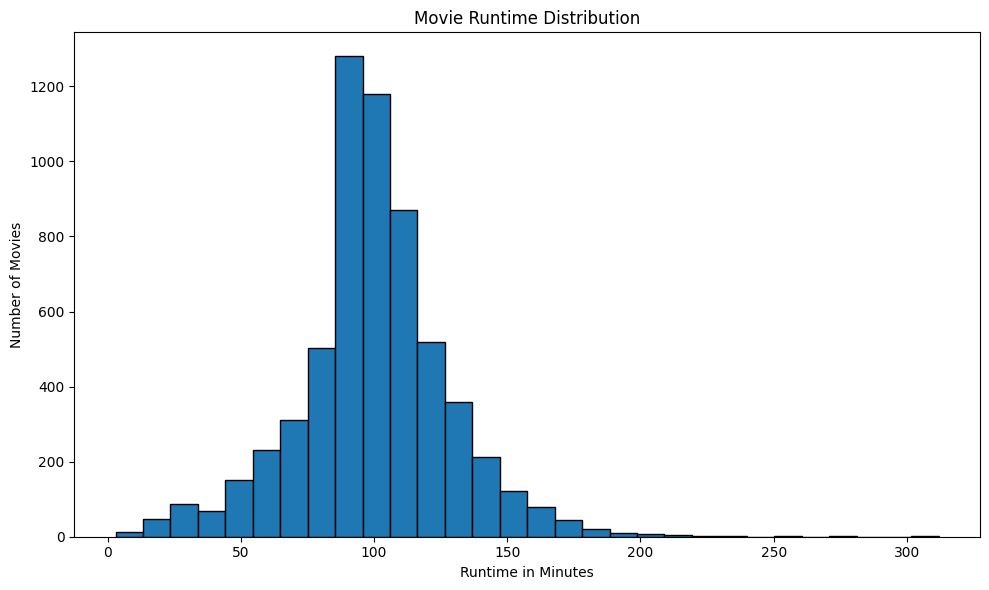

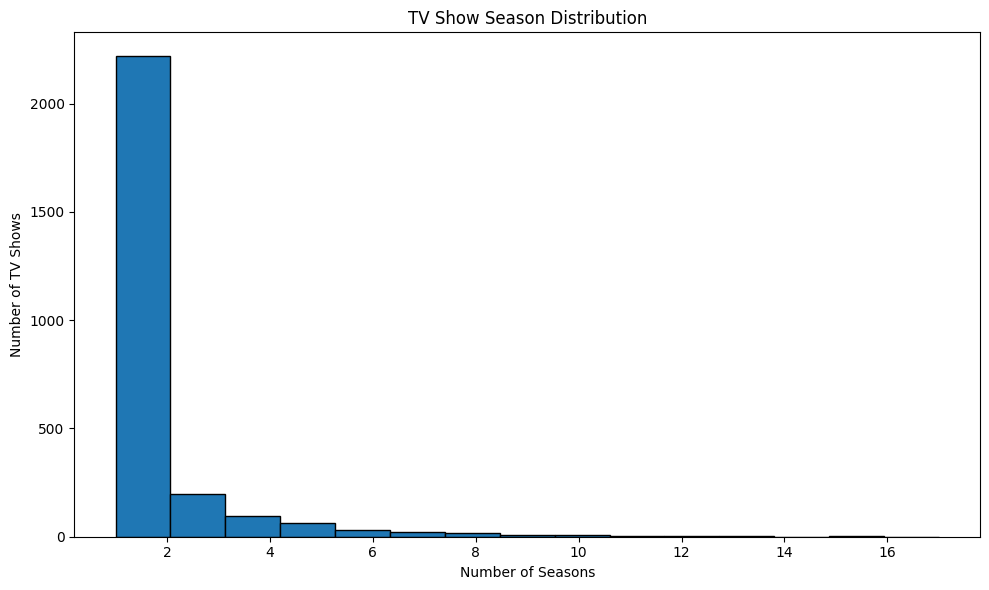

In [16]:
movies = df[df['type'].eq('Movie')]
tv_shows = df[df['type'].eq('TV Show')]

movies['duration_num'].dropna().plot(kind='hist', bins=30, edgecolor='black', figsize=(10,6), title='Movie Runtime Distribution')
plt.xlabel('Runtime in Minutes')
plt.ylabel('Number of Movies')
plt.tight_layout()
plt.savefig(PLOTS_DIR / '05_movie_runtime_distribution.png', dpi=160)
plt.show()

tv_shows['duration_num'].dropna().plot(kind='hist', bins=15, edgecolor='black', figsize=(10,6), title='TV Show Season Distribution')
plt.xlabel('Number of Seasons')
plt.ylabel('Number of TV Shows')
plt.tight_layout()
plt.savefig(PLOTS_DIR / '06_tv_season_distribution.png', dpi=160)
plt.show()

## 9. Top-10 lists

In [17]:
top_years = df['release_year'].value_counts().head(10)
top_countries = df['country'].dropna().str.split(', ').explode().value_counts().head(10)
top_ratings = df['rating'].value_counts().head(10)

summary_tables = {
    'Top 10 Genres': top_genres,
    'Top 10 Release Years': top_years,
    'Top 10 Countries': top_countries,
    'Top 10 Ratings': top_ratings,
}

for name, table in summary_tables.items():
    print('' + name)
    display(table.reset_index())

Top 10 Genres


,listed_in,count
0,International Movies,2752
1,Dramas,2427
2,Comedies,1674
3,International TV Shows,1351
4,Documentaries,869
5,Action & Adventure,859
6,TV Dramas,763
7,Independent Movies,756
8,Children & Family Movies,641
9,Romantic Movies,616


Top 10 Release Years


,release_year,count
0,2018,1147
1,2017,1032
2,2019,1030
3,2020,953
4,2016,902
5,2021,592
6,2015,560
7,2014,352
8,2013,288
9,2012,237


Top 10 Countries


,country,count
0,United States,3689
1,India,1046
2,United Kingdom,804
3,Canada,445
4,France,393
5,Japan,318
6,Spain,232
7,South Korea,231
8,Germany,226
9,Mexico,169


Top 10 Ratings


,rating,count
0,TV-MA,3207
1,TV-14,2160
2,TV-PG,863
3,R,799
4,PG-13,490
5,TV-Y7,334
6,TV-Y,307
7,PG,287
8,TV-G,220
9,NR,80


## 10. Export summary tables

In [19]:
with pd.ExcelWriter(OUTPUT_DIR / 'summary_tables.xlsx') as writer:
    top_genres.reset_index().to_excel(writer, sheet_name='Top Genres', index=False)
    top_years.reset_index().to_excel(writer, sheet_name='Top Years', index=False)
    top_countries.reset_index().to_excel(writer, sheet_name='Top Countries', index=False)
    top_ratings.reset_index().to_excel(writer, sheet_name='Top Ratings', index=False)

df.to_csv(OUTPUT_DIR / 'cleaned_netflix_titles.csv', index=False)

print('Exports completed.')

Exports completed.


## 11. Final written conclusion

In [20]:
print(f'Total titles: {len(df)}')
print(f"Movies: {type_counts.get('Movie', 0)}")
print(f"TV Shows: {type_counts.get('TV Show', 0)}")
print(f'Most common genre: {top_genres.index[0]}')
print(f'Most common release year: {int(top_years.index[0])}')

Total titles: 8807
Movies: 6131
TV Shows: 2676
Most common genre: International Movies
Most common release year: 2018
